# Image-to-video dRSA

Loads separate image- and video-session `natraster.mat` files, aligns the standard image, 2000 ms image, 2250 ms image, and video responses by shared stimulus identity, aligns the neural responses with sequential model features, and computes image static dRSA and video cross-temporal dRSA.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys
import copy
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
with open("../../config.yaml", 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
)
from project_specific_utils import (
    autoregressive_regress_out, load_natraster, min_max_normalization,
)
from useful_stuff.general_utils import (
    TimeSeries, create_RDM, dyn_linear_encoding, get_lagplot, get_lagplot_subset,
)
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.II import dynInformationImbalance


In [48]:
@dataclass
class Cfg:
    vid_exp_name: str = "baby1_260716to24" #"red_20260720to24" # 
    img_exp_name: str = "baby1_260718to27" #"red_20260726to27" #  # 
    image_prefix: str = "img_"
    image_2000ms_prefix: str = "img_2000ms_"
    image_2250ms_prefix: str = "img_2250ms_"
    video_prefix: str = "vid_"

    # MATLAB channels 84--186 inclusive; Python stop indices are exclusive.
    good_channels: tuple[int, int] =  (101,109) # None #  (84, 186)
    top_k = None #10
    smoothing = 3
    image_crop_ms: int = 1000
    new_fs: float | None = 100  # Set to None to keep the original 1000 Hz.
    normalization: str | None = None  # Supported: None or 'min_max'.
    signal_RDM_metric: str = 'cosine_cnt'
    model_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'spearman'
    video_RSA_metric: str = 'correlation'
    video_lag_analysis_end_ms: float = 2500
    video_max_lag_ms: float = 700
    model_name: str = 'ijepa_vith14_1k'
    model_dataset_name: str = 'static_dynamic'
    model_pooling: str | None = 'mean'
    model_features_dir: Path | None = None
    example_layer = 30
    linewidth=3


cfg = Cfg()
cfg
vid_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.vid_exp_name}_natraster_vid.mat'
img_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.img_exp_name}_natraster_img.mat'


In [49]:
"""
match_session_rasters
Align image, timed-image, and video rasters by shared stimulus identity.

INPUT:
    - image_rasters: np.ndarray -> channels x time x image stimuli.
    - image_names: list[str] -> image-session stimulus names.
    - video_rasters: np.ndarray -> channels x time x video stimuli.
    - video_names: list[str] -> video-session stimulus names.
    - image_prefix: str -> filename prefix for the standard image condition.
    - image_2000ms_prefix: str -> filename prefix for the 2000 ms condition.
    - image_2250ms_prefix: str -> filename prefix for the 2250 ms condition.
    - video_prefix: str -> filename prefix for the video condition.

OUTPUT:
    - aligned_image_rasters: np.ndarray -> image rasters for shared stimuli.
    - aligned_video_rasters: np.ndarray -> video rasters in matching order.
    - aligned_image_2000ms_rasters: np.ndarray -> 2000 ms rasters in matching order.
    - aligned_image_2250ms_rasters: np.ndarray -> 2250 ms rasters in matching order.
    - shared_stimuli: list[str] -> identities present in all four conditions.
    - aligned_image_names: list[str] -> retained image stimulus names.
    - aligned_video_names: list[str] -> retained video stimulus names.
    - aligned_image_2000ms_names: list[str] -> retained 2000 ms stimulus names.
    - aligned_image_2250ms_names: list[str] -> retained 2250 ms stimulus names.
"""
def match_session_rasters(
        image_rasters: np.ndarray, image_names: list[str],
        video_rasters: np.ndarray, video_names: list[str],
        image_prefix: str, image_2000ms_prefix: str,
        image_2250ms_prefix: str, video_prefix: str,
        ) -> tuple[
            np.ndarray, np.ndarray, np.ndarray, np.ndarray,
            list[str], list[str], list[str], list[str], list[str],
            ]:
    image_indices_by_condition = {
        'image': {},
        'image_2000ms': {},
        'image_2250ms': {},
    }

    # Assign every image-session stimulus to exactly one image condition.
    for index, name in enumerate(image_names):
        stimulus_stem = Path(name).stem
        if stimulus_stem.startswith(image_2000ms_prefix):
            condition_name = 'image_2000ms'
            stimulus_identity = stimulus_stem[len(image_2000ms_prefix):]
        elif stimulus_stem.startswith(image_2250ms_prefix):
            condition_name = 'image_2250ms'
            stimulus_identity = stimulus_stem[len(image_2250ms_prefix):]
        elif stimulus_stem.startswith(image_prefix):
            condition_name = 'image'
            stimulus_identity = stimulus_stem[len(image_prefix):]
        else:
            continue
        # end if stimulus_stem.startswith

        condition_indices = image_indices_by_condition[condition_name]
        if stimulus_identity in condition_indices:
            raise ValueError(
                f'Duplicate {condition_name} stimulus identity: {stimulus_identity!r}.'
            )
        # end if stimulus_identity in condition_indices
        condition_indices[stimulus_identity] = index
    # end for index, name

    video_index_by_key = {}
    for index, name in enumerate(video_names):
        stimulus_stem = Path(name).stem
        if not stimulus_stem.startswith(video_prefix):
            continue
        # end if not stimulus_stem.startswith(video_prefix)
        stimulus_identity = stimulus_stem[len(video_prefix):]
        if stimulus_identity in video_index_by_key:
            raise ValueError(
                f'Duplicate video stimulus identity: {stimulus_identity!r}.'
            )
        # end if stimulus_identity in video_index_by_key
        video_index_by_key[stimulus_identity] = index
    # end for index, name

    image_index_by_key = image_indices_by_condition['image']
    image_2000ms_index_by_key = image_indices_by_condition['image_2000ms']
    image_2250ms_index_by_key = image_indices_by_condition['image_2250ms']

    # Preserve the standard image order and retain identities found in all conditions.
    shared_stimuli = [
        stimulus_identity for stimulus_identity in image_index_by_key
        if stimulus_identity in video_index_by_key
        and stimulus_identity in image_2000ms_index_by_key
        and stimulus_identity in image_2250ms_index_by_key
    ]
    if len(shared_stimuli) < 2:
        raise ValueError('Need at least two stimulus identities shared by all conditions.')
    # end if len(shared_stimuli)

    image_order = [image_index_by_key[key] for key in shared_stimuli]
    video_order = [video_index_by_key[key] for key in shared_stimuli]
    image_2000ms_order = [image_2000ms_index_by_key[key] for key in shared_stimuli]
    image_2250ms_order = [image_2250ms_index_by_key[key] for key in shared_stimuli]
    aligned_image_names = [image_names[index] for index in image_order]
    aligned_video_names = [video_names[index] for index in video_order]
    aligned_image_2000ms_names = [
        image_names[index] for index in image_2000ms_order
    ]
    aligned_image_2250ms_names = [
        image_names[index] for index in image_2250ms_order
    ]
    return (
        image_rasters[:, :, image_order],
        video_rasters[:, :, video_order],
        image_rasters[:, :, image_2000ms_order],
        image_rasters[:, :, image_2250ms_order],
        shared_stimuli,
        aligned_image_names,
        aligned_video_names,
        aligned_image_2000ms_names,
        aligned_image_2250ms_names,
    )
# EOF


In [50]:
loaded_vid_rasters, vid_stimulus_names = load_natraster(vid_natraster_mat_path)
loaded_img_rasters, img_stimulus_names = load_natraster(img_natraster_mat_path)

In [51]:
loaded_img_rasters.shape

(383, 1000, 300)

In [52]:
(
    image_rasters,
    video_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    image_names,
    video_names,
    image_2000ms_names,
    image_2250ms_names,
) = match_session_rasters(
    loaded_img_rasters, img_stimulus_names,
    loaded_vid_rasters, vid_stimulus_names,
    cfg.image_prefix, cfg.image_2000ms_prefix,
    cfg.image_2250ms_prefix, cfg.video_prefix,
)
print(
    f'{len(shared_stimuli)} stimuli aligned across image, 2000 ms, '
    '2250 ms, and video conditions'
)


if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
    image_ts = TimeSeries(image_rasters[channel_slice, :, :], fs=1000)
    image_2000ms_ts = TimeSeries(image_2000ms_rasters[channel_slice, :, :], fs=1000)
    image_2250ms_ts = TimeSeries(image_2250ms_rasters[channel_slice, :, :], fs=1000)
    video_ts = TimeSeries(video_rasters[channel_slice, :, :], fs=1000)
else:
    # Score each element along axis 0 by its maximum over axes 1 and 2
    if cfg.top_k is not None:
        scores = video_rasters.max(axis=(1, 2))      # shape (N,)    
        top_idx = np.argsort(scores)[-cfg.top_k:][::-1]
        image_ts = TimeSeries(image_rasters[top_idx, :, :], fs=1000)
        image_2000ms_ts = TimeSeries(image_2000ms_rasters[top_idx, :, :], fs=1000)
        image_2250ms_ts = TimeSeries(image_2250ms_rasters[top_idx, :, :], fs=1000)
        video_ts = TimeSeries(video_rasters[top_idx, :, :], fs=1000)
    else:
        image_ts = TimeSeries(image_rasters, 1000)
        image_2000ms_ts = TimeSeries(image_2000ms_rasters, 1000)
        image_2250ms_ts = TimeSeries(image_2250ms_rasters, 1000)
        video_ts = TimeSeries(video_rasters, 1000)

image_ts.resample(cfg.new_fs)
image_2000ms_ts.resample(cfg.new_fs)
image_2250ms_ts.resample(cfg.new_fs)
video_ts.resample(cfg.new_fs)

100 stimuli aligned across image, 2000 ms, 2250 ms, and video conditions


In [53]:
print(f'Image: {image_ts.shape()}')
print(f'2000 ms image: {image_2000ms_ts.shape()}')
print(f'2250 ms image: {image_2250ms_ts.shape()}')
print(f'Video: {video_ts.shape()}')

Image: (9, 100, 100)
2000 ms image: (9, 100, 100)
2250 ms image: (9, 100, 100)
Video: (9, 350, 100)


Text(0.5, 1.0, 'full image rasters')

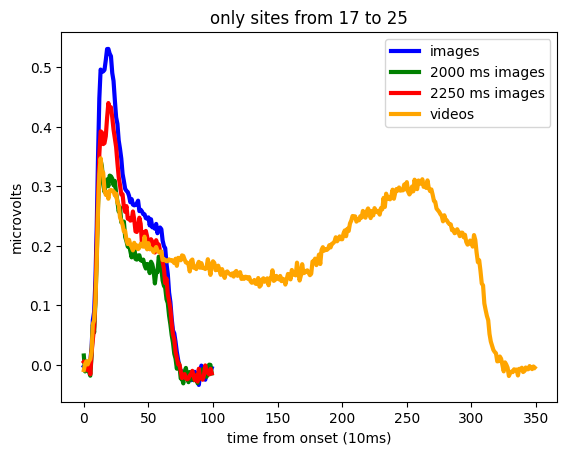

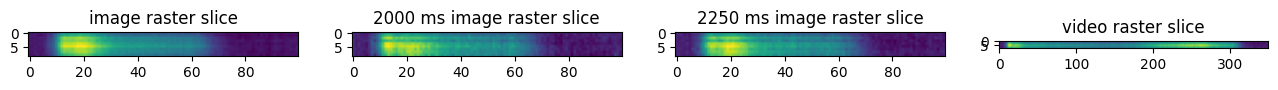

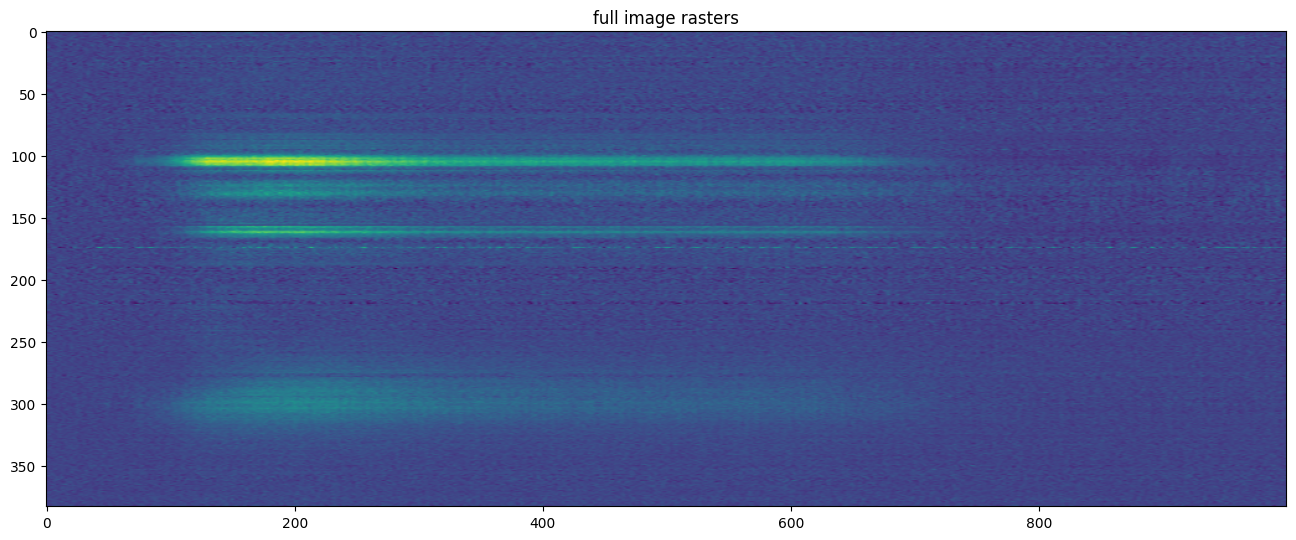

In [54]:
plt.plot(np.mean(image_ts.array[:, :, :], axis=(0,2)).T, color="blue", label="images", linewidth=cfg.linewidth)
plt.plot(np.mean(image_2000ms_ts.array, axis=(0,2)).T, color="green", label="2000 ms images", linewidth=cfg.linewidth)
plt.plot(np.mean(image_2250ms_ts.array, axis=(0,2)).T, color="red", label="2250 ms images", linewidth=cfg.linewidth)
plt.plot(np.mean(video_ts.array[:, :, :], axis=(0,2)).T, color="orange", label="videos", linewidth=cfg.linewidth)
plt.title("only sites from 17 to 25")
plt.ylabel("microvolts")
plt.xlabel("time from onset (10ms)")
plt.legend()
fig, ax = plt.subplots(1, 4, figsize=(16, 10))
ax[0].imshow(np.mean(image_ts.array, axis=2))
ax[0].set_title("image raster slice")
ax[1].imshow(np.mean(image_2000ms_ts.array, axis=2))
ax[1].set_title("2000 ms image raster slice")
ax[2].imshow(np.mean(image_2250ms_ts.array, axis=2))
ax[2].set_title("2250 ms image raster slice")
ax[3].imshow(np.mean(video_ts.array, axis=2))
ax[3].set_title("video raster slice")
fig = plt.figure(figsize=(16,18))
plt.imshow(np.mean(image_rasters, axis=2))
plt.title("full image rasters")


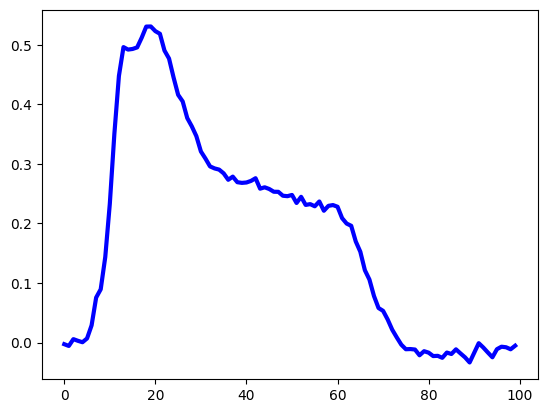

In [55]:
plt.plot(np.mean(image_ts.array[:, :, :], axis=(0,2)).T, color="blue", label="images", linewidth=cfg.linewidth)
# plt.plot(np.mean(image_2000ms_ts.array, axis=(0,2)).T, color="green", label="2000 ms images", linewidth=cfg.linewidth)
# plt.plot(np.mean(image_2250ms_ts.array, axis=(0,2)).T, color="red", label="2250 ms images", linewidth=cfg.linewidth)
# plt.plot(np.mean(video_ts.array[:, :, :], axis=(0,2)).T, color="orange", label="videos", linewidth=cfg.linewidth)
# plt.title("only sites from 17 to 25")
# plt.ylabel("microvolts")
# plt.xlabel("time from onset (10ms)")
# plt.legend()
# fig, ax = plt.subplots(1, 4, figsize=(16, 10))
# ax[0].imshow(np.mean(image_ts.array, axis=2))
# ax[0].set_title("image raster slice")
# ax[1].imshow(np.mean(image_2000ms_ts.array, axis=2))
# ax[1].set_title("2000 ms image raster slice")
# ax[2].imshow(np.mean(image_2250ms_ts.array, axis=2))
# ax[2].set_title("2250 ms image raster slice")
# ax[3].imshow(np.mean(video_ts.array, axis=2))
# ax[3].set_title("video raster slice")
# fig = plt.figure(figsize=(16,18))
# plt.imshow(np.mean(image_rasters, axis=2))
# plt.title("full image rasters")


# DNN-dynamics style RSA

In [56]:
# Load all extracted model layers in numeric order (layer 0, 1, ..., 23).
model_features_dir = cfg.model_features_dir or Path(paths['data_path']) / 'models'
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)

# Reuse the shared subset so image and video model RDMs contain identical stimuli.
image_names_all = [Path(name).name for name in image_names]
video_names_all = [Path(name).name for name in video_names]
# Static image analyses use the final frame from the matching video feature set.
image_model_names = video_names_all

image_neural_ts = TimeSeries(
    image_rasters[:, :cfg.image_crop_ms, :], fs=1000,
)
video_neural_ts = TimeSeries(
    video_rasters, fs=1000,
)
if cfg.new_fs is not None:
    image_neural_ts.resample(cfg.new_fs)
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

if cfg.normalization == 'min_max':
    # Re-estimate shared bounds using every condition included in the model analyses.
    normalization_reference = np.concatenate([
        image_neural_ts.get_array().reshape(image_neural_ts.shape()[0], -1),
        video_neural_ts.get_array().reshape(video_neural_ts.shape()[0], -1),
    ], axis=1)
    image_neural_ts.set_array(min_max_normalization(
        image_neural_ts.get_array(), reference_data=normalization_reference,
    ))
    video_neural_ts.set_array(min_max_normalization(
        video_neural_ts.get_array(), reference_data=normalization_reference,
    ))
# end if cfg.normalization == 'min_max'

print(f'{len(feature_paths)} model layers')
print(f'{len(image_names_all)} image stimuli aligned to final-frame model features')
print(f'{len(video_names_all)} video stimuli aligned to sequential model features')

32 model layers
100 image stimuli aligned to final-frame model features
100 video stimuli aligned to sequential model features


In [57]:
# Compute the neural image RDM once because it is shared by every model layer.
image_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)

image_drsa.compute_RDM_timeseries(image_ts, 'signal')

image_layer_drsa = []
layer_names = []
for feature_path in feature_paths:
    # The final frame has the same visual content as the corresponding static image.
    final_frame_features, layer_name, _ = load_aligned_video_features(
        feature_path, image_model_names, frame_index=-1,
    )
    model_RDM = create_RDM(final_frame_features, metric=cfg.model_RDM_metric)
    image_drsa.set_RDM(model_RDM, 'model')
    image_layer_drsa.append(image_drsa.compute_static_dRSA().get_array().copy())
    layer_names.append(layer_name)
# end for feature_path

image_layer_drsa = np.stack(image_layer_drsa, axis=0)
print(f'Image static dRSA: {image_layer_drsa.shape} (layers, neural time)')

Image static dRSA: (32, 100) (layers, neural time)


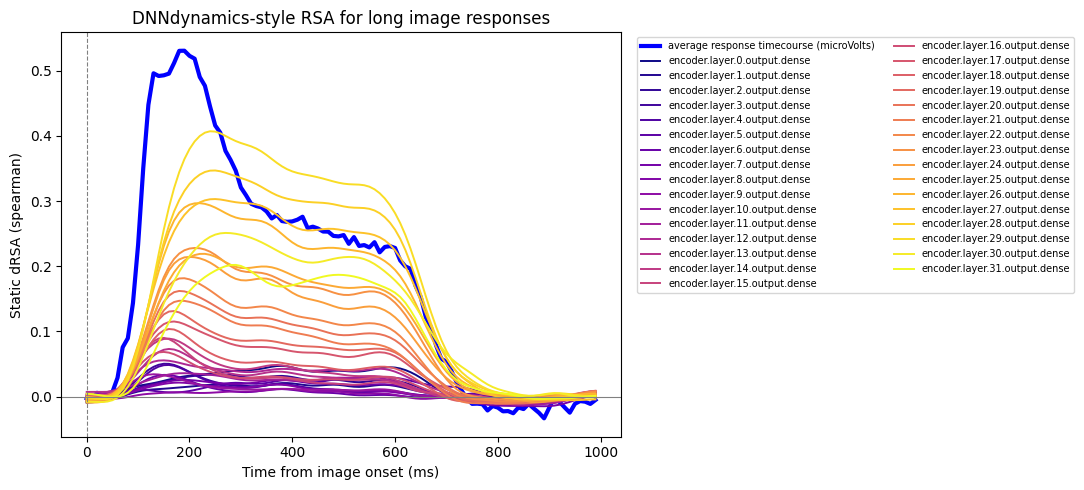

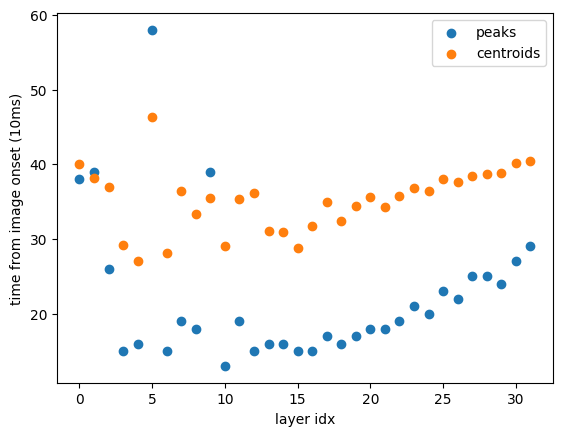

In [58]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(image_time_ms, np.mean(image_ts.array[:, :, :], axis=(0,2)).T, color="blue", label="average response timecourse (microVolts)", linewidth=cfg.linewidth)
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=1.4, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for long image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
plt.figure()
plt.scatter(np.arange(len(tot_peaks)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.ylabel("time from image onset (10ms)")
plt.xlabel("layer idx")
plt.legend()



# Video dRSA
neural video timecourse modelled by frame-wise features


In [59]:
# Compute the neural video RDM once, then replace only the model RDM timecourse.
video_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.video_RSA_metric,
)
video_drsa.compute_RDM_timeseries(video_ts, 'signal')

video_layer_drsa = {}
source_model_fs = None
for feature_path in feature_paths:
    model_features, layer_name, layer_model_fs = load_aligned_video_features(
        feature_path, video_names_all, frame_index=None,
    )

    # Match the model and neural time grids before computing the model RDM timecourse.
    model_ts = TimeSeries(model_features, fs=layer_model_fs)
    model_ts.resample(video_ts.get_fs())
    video_drsa.compute_RDM_timeseries(model_ts, 'model')
    video_layer_drsa[layer_name] = video_drsa.compute_dRSA().copy()

    if source_model_fs is None:
        source_model_fs = layer_model_fs
    elif source_model_fs != layer_model_fs:
        raise ValueError('Model layers have inconsistent source frame rates.')
    # end if source_model_fs is None
# end for feature_path

model_fs = video_neural_ts.get_fs()

example_video_drsa = video_layer_drsa[layer_names[cfg.example_layer]]
neural_time_ms = np.arange(example_video_drsa.shape[0]) * 1000 / video_neural_ts.get_fs()
model_time_ms = np.arange(example_video_drsa.shape[1]) * 1000 / model_fs
print(
    f'{cfg.example_layer} video dRSA: {example_video_drsa.shape} (neural time, model time); '
    f'model features resampled from {source_model_fs:g} to {model_fs:g} Hz'
)

30 video dRSA: (350, 300) (neural time, model time); model features resampled from 60 to 100 Hz


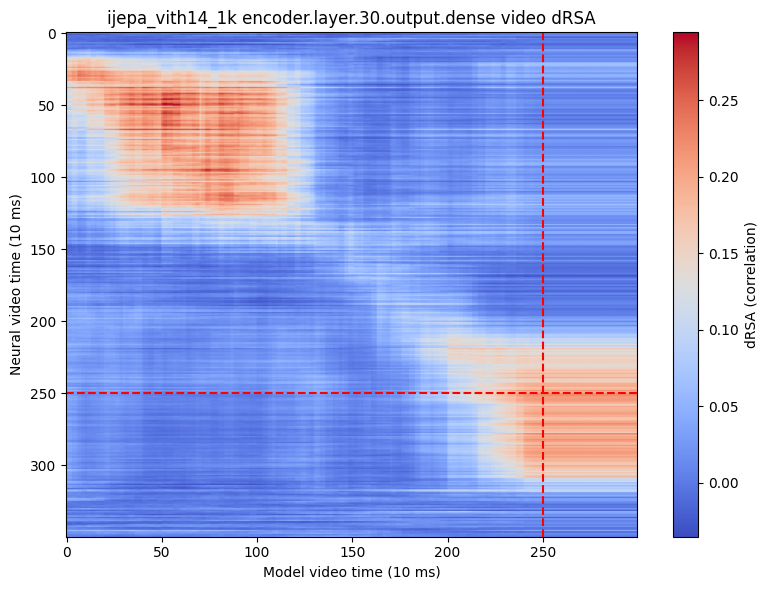

In [60]:
last_frame_ms = 2500
last_frame_idx = int(last_frame_ms*cfg.new_fs/1000)
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    example_video_drsa, aspect='auto', origin='upper', cmap='coolwarm',
)
ax.axvline(last_frame_idx, linestyle="--", color="red")
ax.axhline(last_frame_idx, linestyle="--", color="red")
ax.set(xlabel='Model video time (10 ms)', ylabel='Neural video time (10 ms)',
       title=f'{cfg.model_name} {layer_names[cfg.example_layer]} video dRSA')
fig.colorbar(image, ax=ax, label=f'dRSA ({cfg.video_RSA_metric})')
fig.tight_layout()

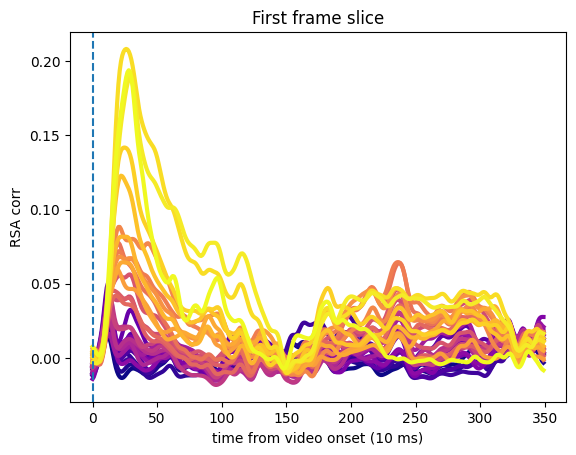

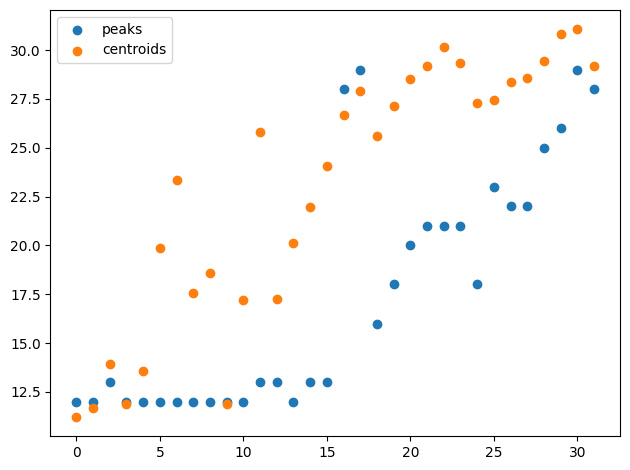

In [61]:
first_frame_ms = 0
beginning_ms, end_ms = 0, 500
beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
first_frame_idx = int(first_frame_ms*cfg.new_fs/1000)
tot_centroids = []
tot_peaks = []
window = 7  # smoothing window (samples)
kernel = np.ones(window) / window
# fig, ax = plt.subplots(1,2,figsize=(10,6))
for idx, l in enumerate(layer_names):
    drsa_mat = video_layer_drsa[l]
    if cfg.smoothing:
        lp = gaussian_filter1d(drsa_mat[:,first_frame_idx], sigma=cfg.smoothing)#kernel, mode="same")
    # lp[lp<0] = 0
    nonzero_lp = copy.deepcopy(lp)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp[beginning_idx:end_idx]/np.sum(nonzero_lp[beginning_idx:end_idx])
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    plt.plot(lp, color=layer_colors[idx], linewidth=cfg.linewidth)
plt.axvline(first_frame_idx, linestyle="--")
# ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
plt.ylabel("RSA corr")
plt.xlabel("time from video onset (10 ms)")
plt.title("First frame slice")
plt.figure()
plt.scatter(np.arange(len(tot_centroids)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.legend()
plt.tight_layout()

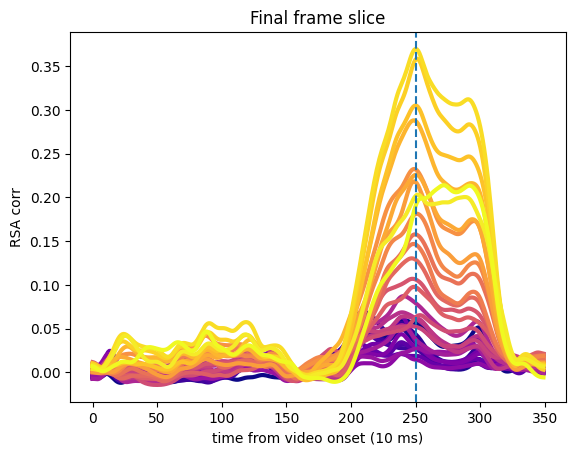

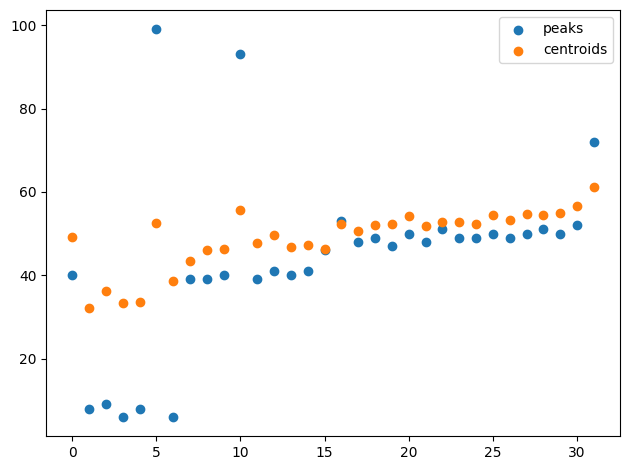

In [62]:
beginning_ms, end_ms = 2000, 3000
beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)

tot_centroids = []
tot_peaks = []
window = 7  # smoothing window (samples)
kernel = np.ones(window) / window
# fig, ax = plt.subplots(1,2,figsize=(10,6))
for idx, l in enumerate(layer_names):
    drsa_mat = video_layer_drsa[l]
    lp = gaussian_filter1d(drsa_mat[:,last_frame_idx], sigma=4)#kernel, mode="same")
    # lp[lp<0] = 0
    nonzero_lp = copy.deepcopy(lp)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp[beginning_idx:end_idx]/np.sum(nonzero_lp[beginning_idx:end_idx])
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    plt.plot(lp, color=layer_colors[idx], linewidth=cfg.linewidth)
plt.axvline(last_frame_idx, linestyle="--")
# ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
plt.ylabel("RSA corr")
plt.xlabel("time from video onset (10 ms)")
plt.title("Final frame slice")
plt.figure()
plt.scatter(np.arange(len(tot_centroids)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.legend()
plt.tight_layout()

In [63]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs
# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(10,100), model_idx=range(10,100), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("time from video onset (ms)")
# plt.title("From 0 to 1000ms")


In [64]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(80,250), model_idx=range(80,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


In [65]:
# max_lag = 30
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(200,250), model_idx=range(200,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


# Raw lagged correlation between image and video neural activity

In [66]:
running_sum = None
for i in range(video_ts.shape()[2]):
    v = TimeSeries(video_ts.array[:,:,i], cfg.new_fs)
    i = TimeSeries(image_ts.array[:,:,i], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i)
    else:
        running_sum += v.lagged_corr(i)

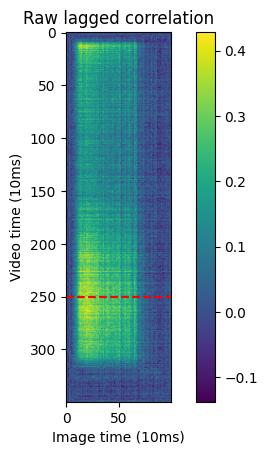

In [67]:
plt.imshow(running_sum/video_ts.shape()[2])
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("Raw lagged correlation")
plt.xlabel("Image time (10ms)")
plt.ylabel("Video time (10ms)")
plt.colorbar()

# Static-perception dRSA comparisons

## 1. Final-frame static perception

This is the baseline image–movie dRSA. The **standard image condition** shows the same visual content as the movie's final frame. The matrix compares the time-resolved movie neural RDM (rows) with the time-resolved static-image neural RDM (columns), after matching stimulus identity across conditions.

In [68]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
drsa.compute_both_RDM_timeseries(video_ts, image_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


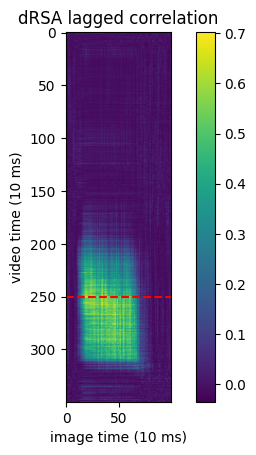

In [69]:
plt.imshow(corr_mat)
plt.ylabel("video time (10 ms)")
plt.xlabel("image time (10 ms)")
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("dRSA lagged correlation")
plt.colorbar()


In [70]:
mat, lp = drsa.signal_RDM_timeseries.autocorr()

In [71]:
mat[200:300, 200:300].shape

(100, 100)

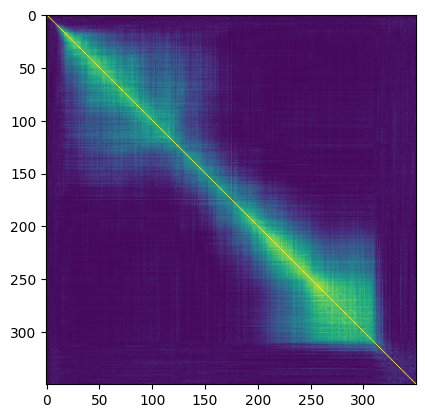

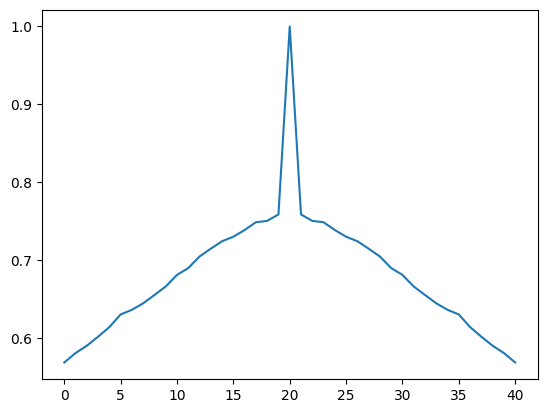

In [72]:
plt.imshow(mat)
plt.figure()
plt.plot(get_lagplot(mat[200:300, 200:300], max_lag=20))

array([[-7.51446734e-03,  5.24221416e-03,  9.77933607e-03, ...,
        -4.71810466e-03,  1.07497415e-02, -1.29268641e-02],
       [ 5.49652751e-03, -5.67102435e-05, -2.79770727e-03, ...,
        -7.90806383e-03,  1.51441494e-02, -1.23000316e-02],
       [ 1.51346762e-03, -8.69226033e-03,  6.41993371e-03, ...,
        -1.41586280e-02,  1.82494361e-02, -1.03338422e-02],
       ...,
       [-1.93184965e-02,  2.68047096e-02,  1.38637761e-02, ...,
         7.38440832e-02,  7.31398469e-03, -1.07006237e-03],
       [ 2.20383599e-03,  2.78882633e-02,  3.46648886e-02, ...,
         3.13220923e-02, -7.48826763e-05, -1.05806711e-02],
       [-1.11269213e-02,  2.22393019e-02,  1.74824935e-02, ...,
         2.12618982e-02,  6.05350479e-03, -8.17545613e-03]],
      shape=(100, 100))

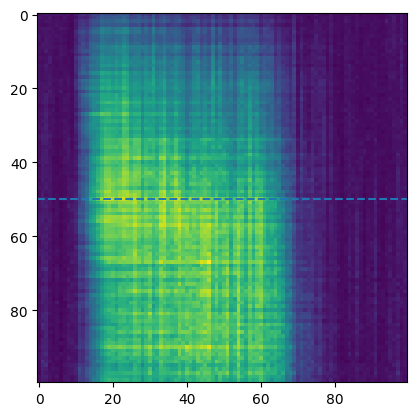

In [73]:
plt.imshow(corr_mat[200:300, :])
plt.axhline(50, linestyle="--")
corr_mat[200:300, :]

Text(0.5, 1.0, 'Static to dynamic lagplot')

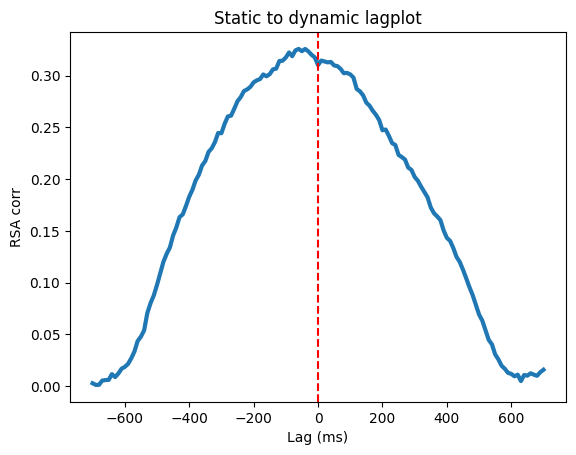

In [74]:
max_lag = 70
lagplot = get_lagplot(corr_mat[250:340, 10:100], max_lag=max_lag)
lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

plt.plot(lags, lagplot, linewidth=cfg.linewidth)
plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Lag (ms)")
plt.ylabel("RSA corr")
plt.title("Static to dynamic lagplot")


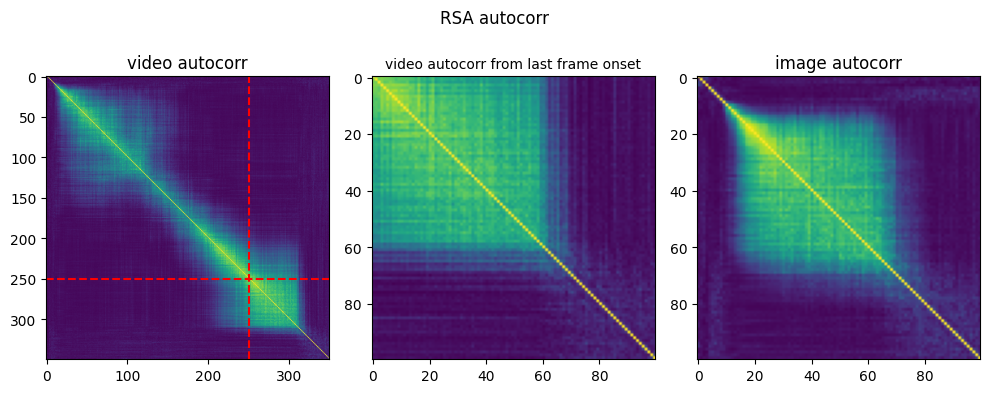

In [75]:
fig, ax = plt.subplots(1,3, figsize=(10,4))

ax[0].imshow(autocorr_vid)
ax[0].set_title("video autocorr")
ax[0].axhline(last_frame_idx, linestyle="--", color="red")
ax[0].axvline(last_frame_idx, linestyle="--", color="red")
ax[1].imshow(autocorr_vid[last_frame_idx:, last_frame_idx:])
ax[1].set_title("video autocorr from last frame onset", fontsize=10)
ax[2].imshow(autocorr_img)
ax[2].set_title("image autocorr")
fig.suptitle("RSA autocorr")
fig.tight_layout()

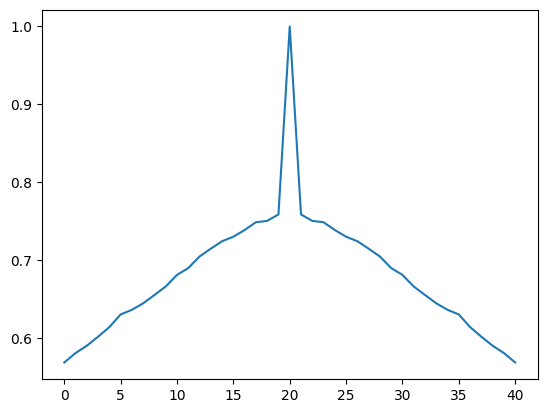

In [76]:
plt.plot(get_lagplot(autocorr_vid[200:300, 200:300], max_lag=20))

### Optional symmetric delay embedding of the raw responses

This exploratory variant embeds both raw responses over `(-5, 5)` samples before constructing RDMs. Because it includes past and future samples, it is **non-causal** and is separate from the causal autoregressive predictor introduced below.

In [77]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
delay_emb_video_ts = video_ts.delay_embeddings(lags=(-5, 5), pad_mode="edge")
delay_emb_image_ts = image_ts.delay_embeddings(lags=(-5, 5), pad_mode="edge")
drsa.compute_both_RDM_timeseries(delay_emb_video_ts, delay_emb_image_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


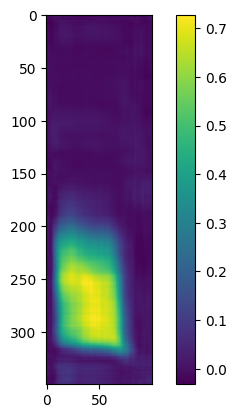

In [78]:
plt.imshow(corr_mat)
plt.colorbar()

## 2. Static perception 500 ms before the final frame

The `image_2000ms_ts` condition presents the matching static frame at 2000 ms, which is 500 ms before the movie's final-frame onset at 2500 ms. This dRSA asks whether that earlier static response follows the movie's representational trajectory.

In [79]:
drsa_500ms_before = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
drsa_500ms_before.compute_both_RDM_timeseries(
    video_ts, image_2000ms_ts,
)
corr_mat_500ms_before = drsa_500ms_before.compute_dRSA()


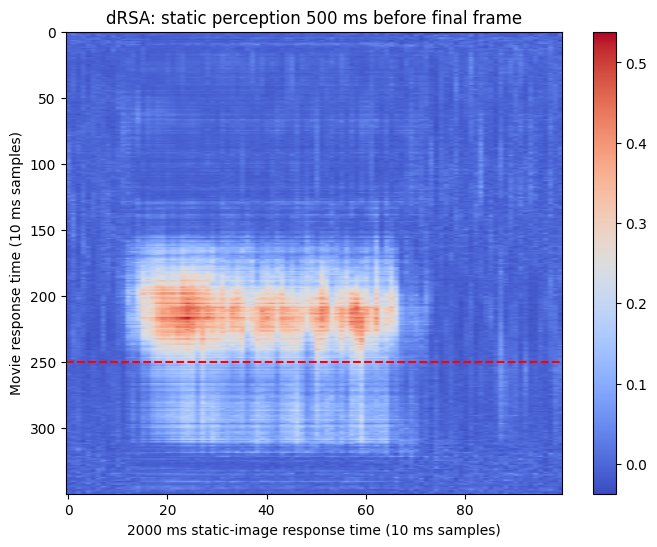

In [80]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    corr_mat_500ms_before, aspect="auto", origin="upper",
    cmap="coolwarm",
)
ax.axhline(last_frame_idx, linestyle="--", color="red")
ax.set_title("dRSA: static perception 500 ms before final frame")
ax.set_xlabel("2000 ms static-image response time (10 ms samples)")
ax.set_ylabel("Movie response time (10 ms samples)")
fig.colorbar(image, ax=ax)


## 3. Static perception 250 ms before the final frame

The `image_2250ms_ts` condition presents the matching static frame at 2250 ms, 250 ms before the movie's final-frame onset. This is the closest pre-final-frame static control and uses the same movie-by-image dRSA layout.

In [81]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
drsa.compute_both_RDM_timeseries(video_ts, image_2000ms_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


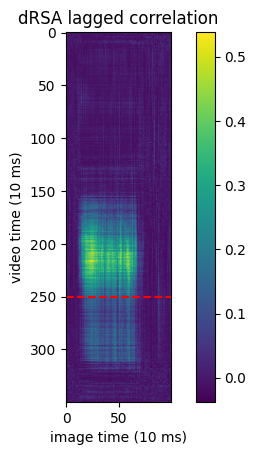

In [82]:
plt.imshow(corr_mat)
plt.ylabel("video time (10 ms)")
plt.xlabel("image time (10 ms)")
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("dRSA lagged correlation")
plt.colorbar()


## 4. dRSA after regressing out an earlier static condition

This cross-condition residualization removes from the standard final-frame static response the component linearly explained by either the 2000 ms (500 ms before) or 2250 ms (250 ms before) static condition. `predictor_mode="window_average"` uses a fixed earlier response summary; `predictor_mode="delay_embedded"` uses a time-resolved lag window. The following dRSA compares the movie response with this residual final-frame static response.

This section is distinct from the autoregressive analysis below: here the predictor is a **different presentation condition**, whereas the autoregressive model predicts each condition from its own past.

In [83]:
@dataclass
class RegressOutCfg:
    delayed_condition: str = "2250ms"  # Supported: "2000ms" or "2250ms".
    predictor_mode: str = "delay_embedded" #"window_average" #
    average_window_ms: tuple[int, int] = (100, 500)
    delay_embedding_lags: tuple[int, int] = (-1, 1)  # Samples at the response sampling rate.
    delay_embedding_pad_mode: str = "edge"
    regression_type: str = "lr"


regress_cfg = RegressOutCfg()

# Select which delayed static-image condition will be regressed out.
delayed_image_ts_by_condition = {
    "2000ms": image_2000ms_ts,
    "2250ms": image_2250ms_ts,
}
if regress_cfg.delayed_condition not in delayed_image_ts_by_condition:
    raise ValueError(
        "delayed_condition must be either '2000ms' or '2250ms', got "
        f"{regress_cfg.delayed_condition!r}."
    )
# end if regress_cfg.delayed_condition
delayed_image_ts = delayed_image_ts_by_condition[regress_cfg.delayed_condition]
target_image_ts = image_ts

# The regression requires matching sampling frequencies, channels, and stimuli.
delayed_array = delayed_image_ts.get_array()
target_array = target_image_ts.get_array()
if delayed_image_ts.get_fs() != target_image_ts.get_fs():
    raise ValueError("The delayed and target image responses have different sampling rates.")
# end if delayed_image_ts.get_fs()
if delayed_array.ndim != 3 or target_array.ndim != 3:
    raise ValueError("Expected image responses with shape channels x time x stimuli.")
# end if delayed_array.ndim
if delayed_array.shape[0] != target_array.shape[0] or delayed_array.shape[2] != target_array.shape[2]:
    raise ValueError("The delayed and target responses must contain matching channels and stimuli.")
# end if delayed_array.shape

if regress_cfg.predictor_mode == "window_average":
    # Average the delayed response over [start_ms, end_ms), then repeat it at each
    # target timepoint so the last-frame response itself remains time resolved.
    window_start_ms, window_end_ms = regress_cfg.average_window_ms
    delayed_fs = delayed_image_ts.get_fs()
    window_start_index = int(round(window_start_ms * delayed_fs / 1000))
    window_end_index = int(round(window_end_ms * delayed_fs / 1000))
    if not 0 <= window_start_index < window_end_index <= len(delayed_image_ts):
        raise ValueError(
            f"Invalid averaging window {regress_cfg.average_window_ms} ms for "
            f"a {delayed_image_ts.get_duration_ms():g} ms response."
        )
    # end if averaging window is invalid
    delayed_window_average = delayed_array[
        :, window_start_index:window_end_index, :
    ].mean(axis=1, keepdims=True)
    predictor_array = np.repeat(
        delayed_window_average, repeats=len(target_image_ts), axis=1,
    )
    predictor_description = f"{window_start_ms}-{window_end_ms} ms average"
elif regress_cfg.predictor_mode == "delay_embedded":
    # Embed the complete delayed response independently for every stimulus.
    delayed_embedded_ts = delayed_image_ts.delay_embeddings(
        lags=regress_cfg.delay_embedding_lags,
        pad_mode=regress_cfg.delay_embedding_pad_mode,
    )
    if len(delayed_embedded_ts) != len(target_image_ts):
        raise ValueError(
            "Delay embedding must preserve the full target duration; use a "
            "non-None delay_embedding_pad_mode such as 'edge'."
        )
    # end if len(delayed_embedded_ts)
    predictor_array = delayed_embedded_ts.get_array()
    predictor_description = (
        f"delay embedding {regress_cfg.delay_embedding_lags} samples"
    )
else:
    raise ValueError(
        "predictor_mode must be either 'window_average' or 'delay_embedded', got "
        f"{regress_cfg.predictor_mode!r}."
    )
# end if regress_cfg.predictor_mode

# pointwise_regress_out expects features x samples. Stack time-stimulus pairs as
# samples, regress, and restore channels x time x stimuli for downstream dRSA.
target_shape = target_array.shape
predictor_for_regression_ts = TimeSeries(
    predictor_array.reshape(predictor_array.shape[0], -1),
    fs=target_image_ts.get_fs(),
)
target_for_regression_ts = TimeSeries(
    target_array.reshape(target_shape[0], -1),
    fs=target_image_ts.get_fs(),
)
regression_model = dyn_linear_encoding(
    regression_type=regress_cfg.regression_type,
    cv_type="same",
    max_lag=0,
)
regressed_flat_ts = regression_model.pointwise_regress_out(
    predictor_for_regression_ts, target_for_regression_ts,
)
image_neural_regressed_ts = TimeSeries(
    regressed_flat_ts.get_array().reshape(target_shape),
    fs=target_image_ts.get_fs(),
)

print(
    f"Regressed the {regress_cfg.delayed_condition} response "
    f"({predictor_description}) from the time-resolved last-frame response."
)
print(f"dRSA-ready residual response: {image_neural_regressed_ts.shape()}")
# Use image_neural_regressed_ts in place of image_ts in compute_RDM_timeseries.
# EOF


Regressed the 2250ms response (delay embedding (-1, 1) samples) from the time-resolved last-frame response.
dRSA-ready residual response: (9, 100, 100)


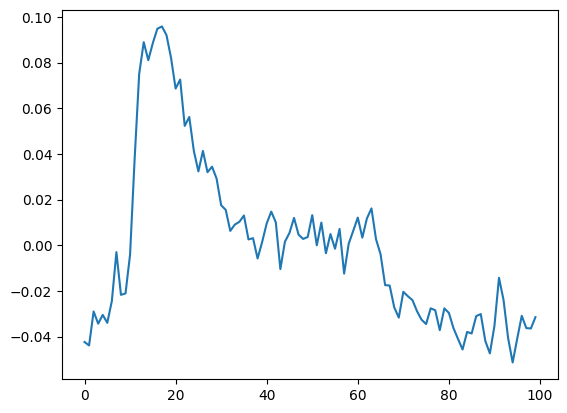

In [84]:
plt.plot(np.mean(image_neural_regressed_ts.array, axis=(0,2)))

In [85]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
drsa.compute_both_RDM_timeseries(video_ts, image_neural_regressed_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


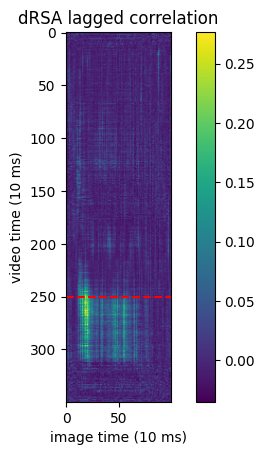

In [86]:
plt.imshow(corr_mat)
plt.ylabel("video time (10 ms)")
plt.xlabel("image time (10 ms)")
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("dRSA lagged correlation")
plt.colorbar()


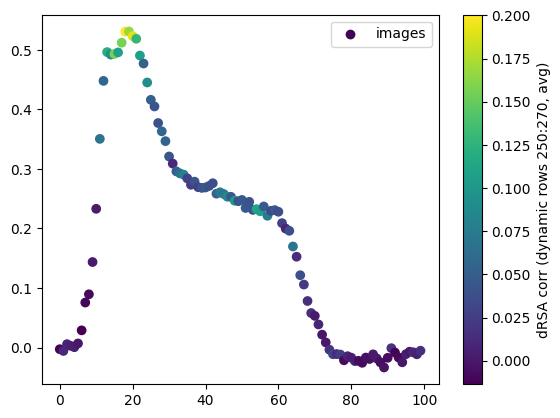

In [87]:
# plot dRSA colors here
static_to_dynamic_corr = corr_mat[240:280, :].mean(axis=0)
image_trace = np.mean(image_ts.array[:, :, :], axis=(0,2)).T
points = plt.scatter(
    np.arange(len(image_trace)), image_trace,
    c=static_to_dynamic_corr, cmap="viridis", label="images",
)
plt.colorbar(points, label="dRSA corr (dynamic rows 250:270, avg)")
plt.legend()

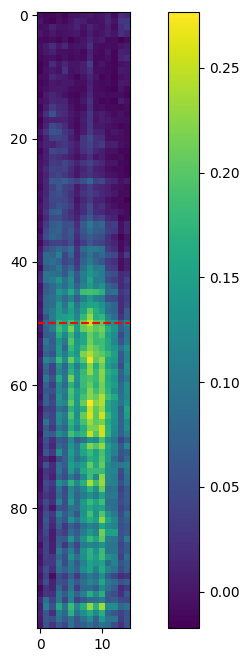

In [88]:
plt.figure(figsize=(10,8))
plt.imshow(corr_mat[200:300,10:25])
plt.axhline(50, linestyle="--", color="red")
plt.colorbar()

Text(0.5, 1.0, 'Static to dynamic lagplot')

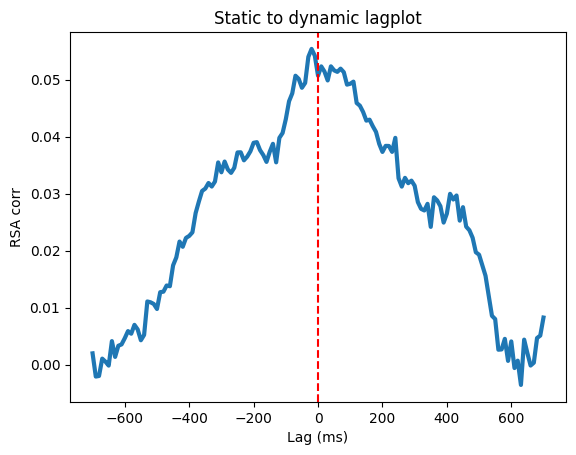

In [89]:
max_lag = 70
lagplot = get_lagplot(corr_mat[250:340, 10:100], max_lag=max_lag)
lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

plt.plot(lags, lagplot, linewidth=cfg.linewidth)
plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Lag (ms)")
plt.ylabel("RSA corr")
plt.title("Static to dynamic lagplot")

In [90]:
running_sum = None
for i in range(video_ts.shape()[2]):
    v = TimeSeries(video_ts.array[:,:,i], cfg.new_fs)
    i = TimeSeries(image_neural_regressed_ts.array[:,:,i], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i)
    else:
        running_sum += v.lagged_corr(i)

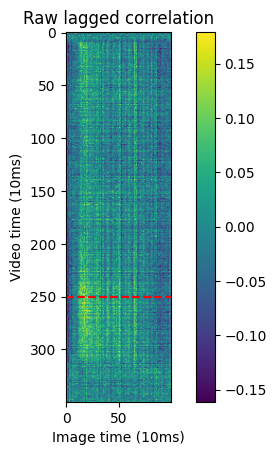

In [91]:
plt.imshow(running_sum/video_ts.shape()[2])
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("Raw lagged correlation")
plt.xlabel("Image time (10ms)")
plt.ylabel("Video time (10ms)")
plt.colorbar()

# Autoregressive residual dRSA

The model fits one shared linear transition across all valid timepoints and stimuli. The closest predictor does not have to be the immediately preceding sample:

$$x(t) = A[x(t-n), x(t-(n+1)), \ldots, x(t-(n+k-1))] + \epsilon(t).$$

`first_delay=n` controls how far back the predictor starts, and `n_delays=k` controls how many consecutive delayed samples are embedded. For example:

- `first_delay=5, n_delays=1` gives $x(t)=Ax(t-5)+\epsilon(t)$.
- `first_delay=5, n_delays=3` uses $[x(t-5),x(t-6),x(t-7)]$.

This lets the regression skip highly redundant adjacent samples when they remove too much variance. At `new_fs=100`, each delay sample is 10 ms, so `first_delay=10` starts 100 ms in the past.

- Set `response_to_residualize="image"` to residualize the standard final-frame static response and compare it with the raw movie response.
- Set `response_to_residualize="movie"` to residualize the movie response and compare it with the raw standard-image response.

No temporal padding is used. Samples before the largest requested lag do not have a complete causal predictor and are excluded. `fit_intercept=False` matches the stated equation exactly; setting it to `True` fits an affine model. The fit is descriptive and in-sample, so the residual should be interpreted as a linear innovation rather than as causal evidence.

In [92]:
@dataclass
class AutoregressiveCfg:
    response_to_residualize: str = "movie"  # Supported: "image" or "movie".
    first_delay: int = 15  # Samples; set >1 to skip adjacent timepoints.
    n_delays: int = 1  # Number of consecutive lags from first_delay.
    regression_type: str = "lr"
    fit_intercept: bool = False


ar_cfg = AutoregressiveCfg()

response_ts_by_name = {
    "image": image_ts,
    "movie": video_ts,
}
if ar_cfg.response_to_residualize not in response_ts_by_name:
    raise ValueError(
        "response_to_residualize must be either 'image' or 'movie', got "
        f"{ar_cfg.response_to_residualize!r}."
    )
# end if ar_cfg.response_to_residualize

ar_source_ts = response_ts_by_name[ar_cfg.response_to_residualize]
ar_residual_ts, ar_model, ar_variance_explained = (
    autoregressive_regress_out(
        ar_source_ts,
        first_delay=ar_cfg.first_delay,
        n_delays=ar_cfg.n_delays,
        regression_type=ar_cfg.regression_type,
        fit_intercept=ar_cfg.fit_intercept,
    )
)
ar_lags = list(range(
    ar_cfg.first_delay,
    ar_cfg.first_delay + ar_cfg.n_delays,
))
ar_maximum_delay = ar_lags[-1]
ar_residual_start_ms = (
    ar_maximum_delay * 1000 / ar_source_ts.get_fs()
)

print(
    f"AR lags {ar_lags} residualized {ar_cfg.response_to_residualize} "
    f"response: {ar_source_ts.shape()} -> {ar_residual_ts.shape()}"
)
print(
    "Mean channel-wise variance removed: "
    f"{np.mean(ar_variance_explained):.3f}"
)
print(f"Autoregressive coefficient shape: {ar_model.get_weights().shape}")


AR lags [15] residualized movie response: (9, 350, 100) -> (9, 335, 100)
Mean channel-wise variance removed: 0.357
Autoregressive coefficient shape: (9, 9)


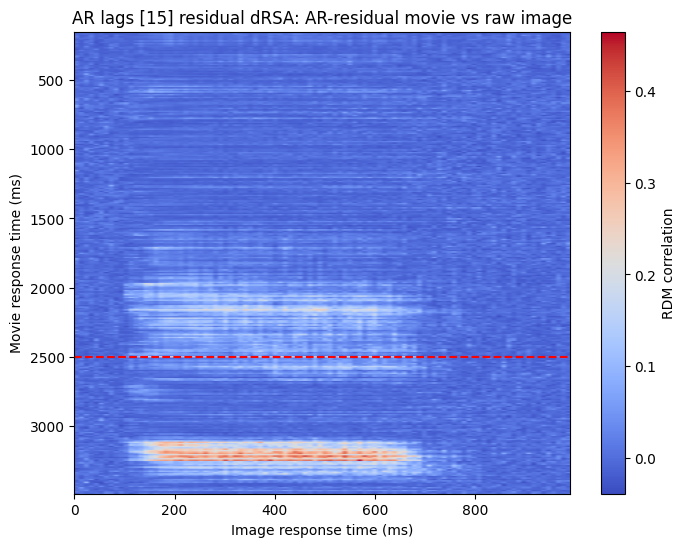

In [93]:
# Keep movie time on the dRSA rows and image time on the columns.
if ar_cfg.response_to_residualize == "image":
    ar_signal_ts = video_ts
    ar_model_ts = ar_residual_ts
    signal_start_ms = 0
    model_start_ms = ar_residual_start_ms
    comparison_description = "raw movie vs AR-residual image"
else:
    ar_signal_ts = ar_residual_ts
    ar_model_ts = image_ts
    signal_start_ms = ar_residual_start_ms
    model_start_ms = 0
    comparison_description = "AR-residual movie vs raw image"
# end if ar_cfg.response_to_residualize

ar_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric="correlation",
)
ar_drsa.compute_both_RDM_timeseries(ar_signal_ts, ar_model_ts)
ar_corr_mat = ar_drsa.compute_dRSA()

signal_time_ms = (
    signal_start_ms
    + np.arange(len(ar_signal_ts)) * 1000 / ar_signal_ts.get_fs()
)
model_time_ms = (
    model_start_ms
    + np.arange(len(ar_model_ts)) * 1000 / ar_model_ts.get_fs()
)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    ar_corr_mat,
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    extent=[
        model_time_ms[0], model_time_ms[-1],
        signal_time_ms[-1], signal_time_ms[0],
    ],
)
if signal_time_ms[0] <= last_frame_ms <= signal_time_ms[-1]:
    ax.axhline(last_frame_ms, linestyle="--", color="red")
# end if last_frame_ms is in the movie range
ax.set_title(f"AR lags {ar_lags} residual dRSA: {comparison_description}")
ax.set_xlabel("Image response time (ms)")
ax.set_ylabel("Movie response time (ms)")
fig.colorbar(image, ax=ax, label="RDM correlation")
